In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
from typing import Union

from pandas import wide_to_long


def read_json(in_file: Union[Path, str]):
    if not isinstance(in_file, Path):
        in_file = Path(in_file)
    return json.loads(in_file.read_text(encoding='utf8'))

In [10]:
METRIC_LIST = ['depth_ratio', 'ops_ratio', 'cx_ratio']

def wide_to_long(df):
    df = pd.melt(
        df,
        id_vars=[col for col in df.columns if col not in METRIC_LIST],
        value_vars=METRIC_LIST,
        var_name='metric',
        value_name='value'
    )
    return df

In [5]:
def get_ours_metrics(dir:  Path):
    if not isinstance(dir, Path):
        dir = Path(dir)
    assert dir.is_dir(), dir

    records = []
    for subdir in dir.iterdir():
        try:
            metrics = read_json(subdir / 'metrics.json')
            config = read_json(subdir / 'config.json')
        except:
            continue
        rec = {key.replace('metric/', ''): value for key, value in metrics.items()}
        rec.update(graph_name=config['hardware'].lower(),
                   circuit=config['circuit'],
                   layout_method=config['init_strategy'].lower() + '-ours',
                   opt_method='ours',
                   routing_method='ours',
                   opt_order='ours')
        records.append(rec)

    return pd.DataFrame.from_records(records)

df_ours = get_ours_metrics('./output/ours/nam_circs')

In [11]:
df_baseline = wide_to_long(pd.read_csv('./output/baseline/nam_circs.csv'))

In [5]:
len(df_ours.circuit.unique()), len(df_baseline.circuit.unique())

NameError: name 'df_ours' is not defined

In [8]:
df = pd.concat([df_ours, df_baseline], axis=0)


In [7]:
df_baseline.describe()

,depth_ratio,ops_ratio,cx_ratio
count,1859.000000,1859.000000,1859.000000
mean,1.573516,1.262179,2.995535
std,0.771797,0.234843,1.380568
min,0.953488,0.845000,1.428571
25%,1.160000,1.120000,2.050505
50%,1.303030,1.212230,2.645161
75%,1.721471,1.332046,3.298437
max,7.640625,2.503386,9.466102


In [26]:
def plot_bar_comparison(df, title, x, hue=None):
    plt.figure(figsize=(15,3))
    plt.suptitle(title)

    for i, metric in enumerate(METRIC_LIST):
        ax = plt.subplot(1,len(METRIC_LIST),i+1)
        sns.barplot(df[df.metric == metric], y='value', x=x, ax=ax, legend=bool(hue), hue=hue)
        ax.set_ylabel('')
        ax.set_xlabel(metric)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

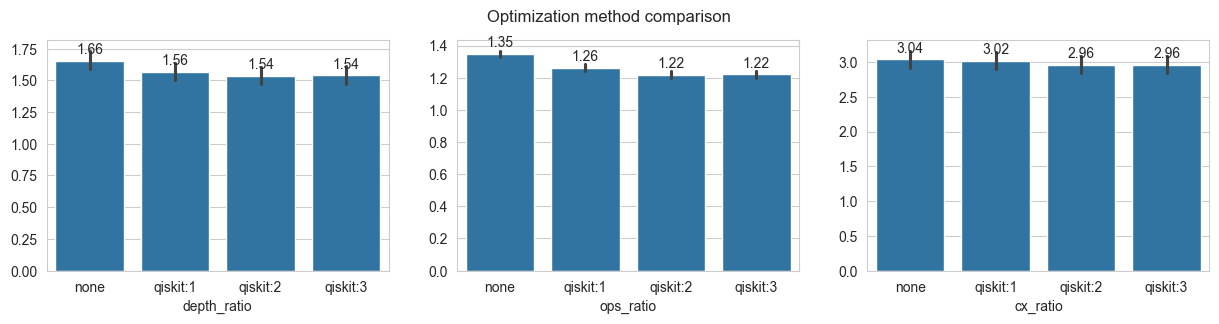

In [20]:
plot_bar_comparison(df_baseline, title='Optimization method comparison', x='opt_method')

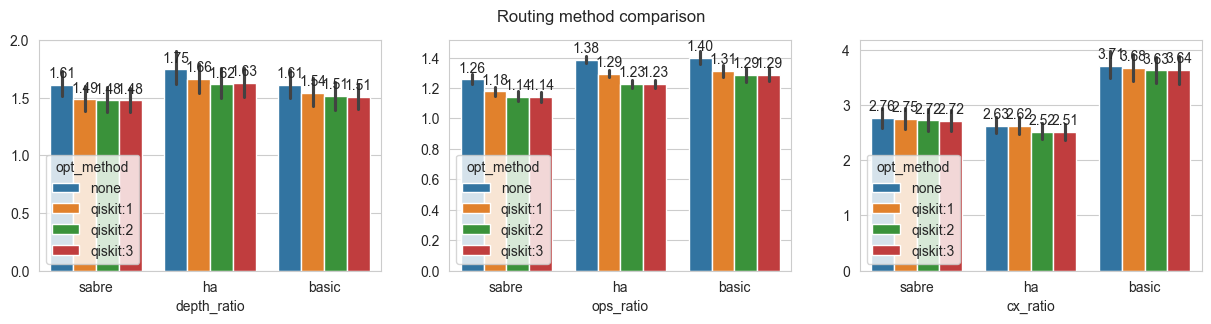

In [27]:
plot_bar_comparison(df_baseline, title='Routing method comparison', x='routing_method', hue='opt_method')


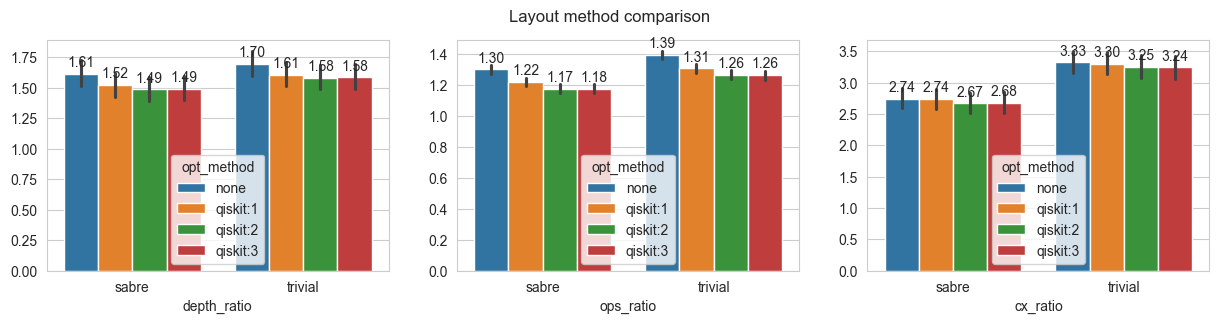

In [28]:
plot_bar_comparison(df_baseline, title='Layout method comparison', x='layout_method', hue='opt_method')